# Full EDA — IT job market on ITviec (29 Sep 2026)

14 presentation-quality charts (font ≥ 12pt, title, axis labels, source caption). Each chart is saved to `reports/figures/eda_<name>.png` for the slides. Plotting code lives in `src/viz/eda.py` (also run by `python scripts/run_pipeline.py figures`).

Every number next to a chart is **printed by code** — slides take numbers from here or from `final_notebook.ipynb`.

**Required data:** `data/processed/jobs_clean.parquet` and `data/processed/skill_matrix.parquet` (download from Drive, or run `python scripts/run_pipeline.py skills`). Hashes must match `docs/MANIFEST.json`.

The notebook only shows aggregate numbers and **never** prints raw job-description text (ToS commitment, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, group_label, load_data, save_figure, salary_tertiles, skill_share

# load_data() checks the SHA-256 of jobs_clean + skill_matrix against docs/MANIFEST.json and stops on mismatch
jobs, skills = load_data()
print(f"{len(jobs)} jobs, {skills.shape[1]} skills — hashes match docs/MANIFEST.json")

688 jobs, 100 skills — hashes match docs/MANIFEST.json


## 1. Data through the pipeline

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_pipeline_funnel.png')

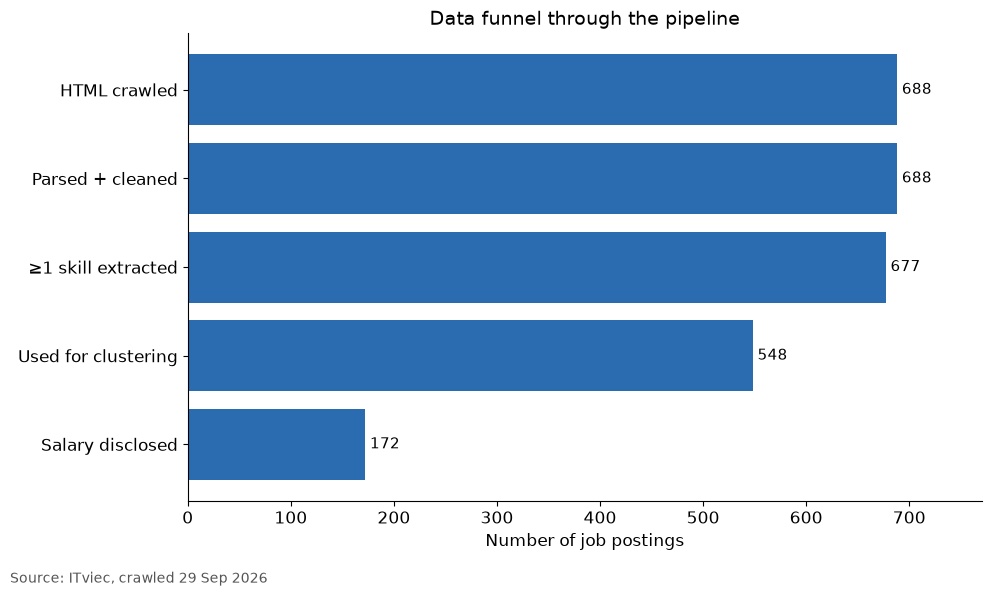

In [2]:
fig = FIGURES["pipeline_funnel"](jobs, skills)
save_figure(fig, "pipeline_funnel")  # → reports/figures/eda_pipeline_funnel.png

## 2. Salary

Salaries come from the JSON-LD `baseSalary` field (the ITviec page hides them behind login — DECISIONS 29/09), converted to million VND per month (fixed USD rate — A9; no gross/net adjustment — A14).

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_disclosure.png')

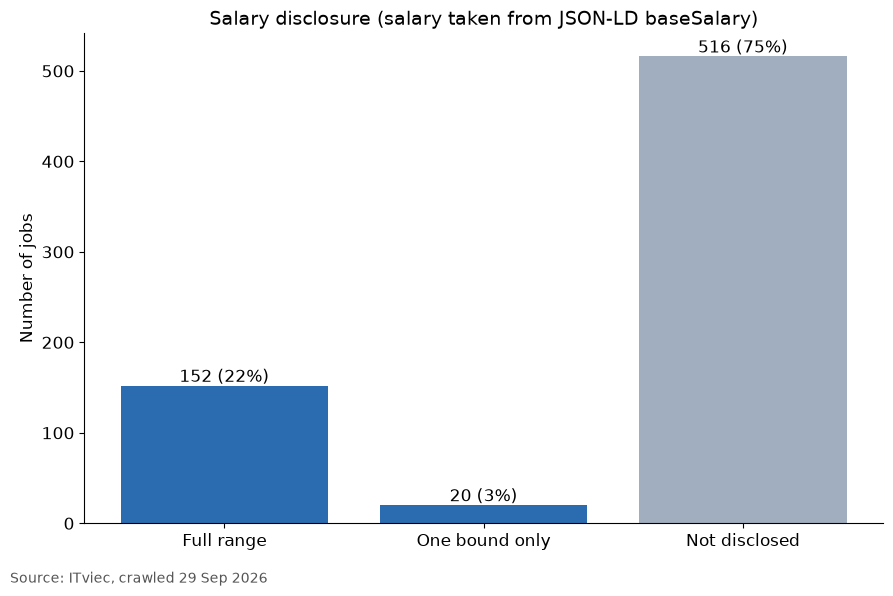

In [3]:
fig = FIGURES["salary_disclosure"](jobs, skills)
save_figure(fig, "salary_disclosure")  # → reports/figures/eda_salary_disclosure.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_distribution.png')

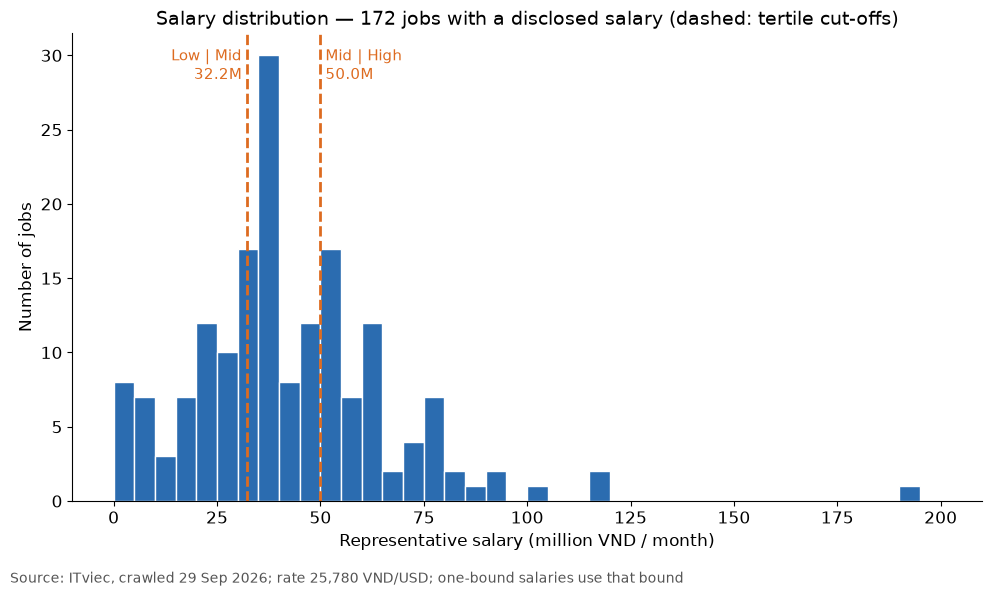

In [4]:
fig = FIGURES["salary_distribution"](jobs, skills)
save_figure(fig, "salary_distribution")  # → reports/figures/eda_salary_distribution.png

In [5]:
paid = jobs.loc[jobs["has_salary"], "salary_mid"]
_, (low, high) = salary_tertiles(jobs)
print(f"Jobs with a salary: {len(paid)}/{len(jobs)} ({len(paid)/len(jobs):.1%})")
print(f"Median {paid.median():.1f}M | Q1 {paid.quantile(.25):.1f} | Q3 {paid.quantile(.75):.1f} | max {paid.max():.1f}")
print(f"Tertile cut-offs: Low < {low:.1f} ≤ Mid < {high:.1f} ≤ High (million VND / month)")

Jobs with a salary: 172/688 (25.0%)
Median 38.7M | Q1 28.4 | Q3 51.6 | max 193.4
Tertile cut-offs: Low < 32.2 ≤ Mid < 50.0 ≤ High (million VND / month)


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_currency.png')

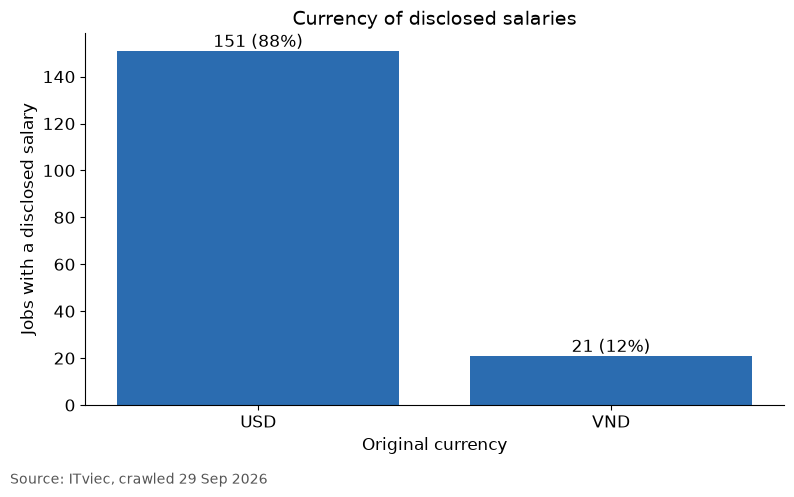

In [6]:
fig = FIGURES["currency"](jobs, skills)
save_figure(fig, "currency")  # → reports/figures/eda_currency.png

## 3. Skills

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_top_skills.png')

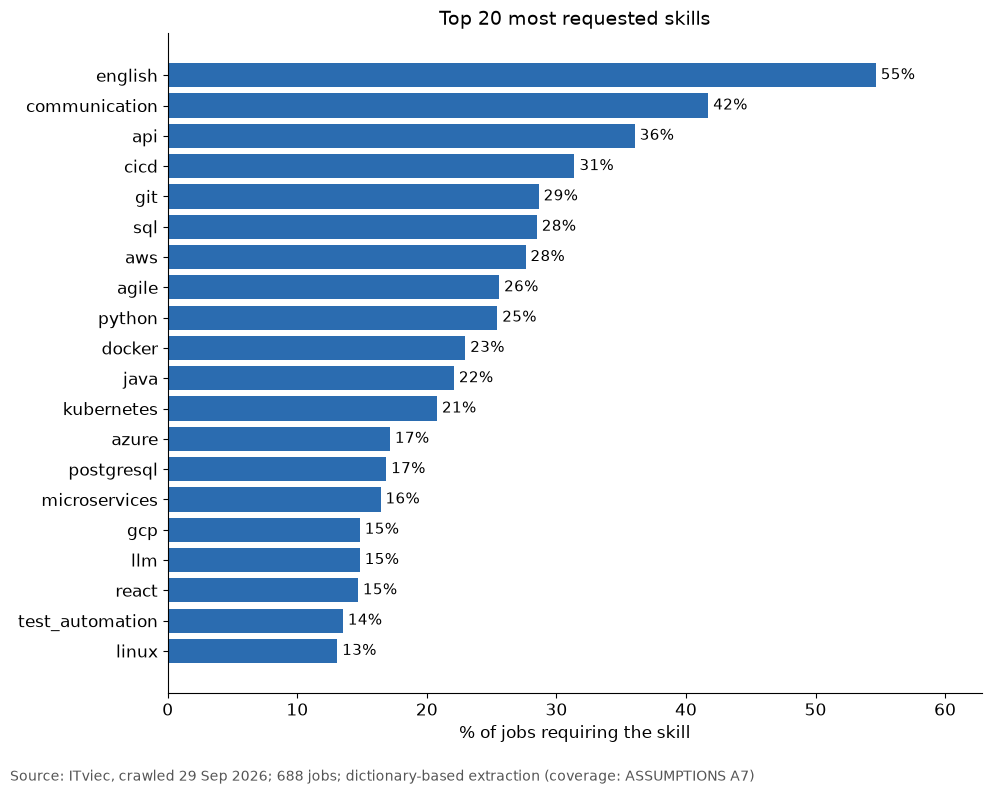

In [7]:
fig = FIGURES["top_skills"](jobs, skills)
save_figure(fig, "top_skills")  # → reports/figures/eda_top_skills.png

In [8]:
share = skill_share(skills)
print("Top 10 skills (% of jobs):")
print((share.head(10) * 100).round(1).to_string())

Top 10 skills (% of jobs):
english          54.7
communication    41.7
api              36.0
cicd             31.4
git              28.6
sql              28.5
aws              27.6
agile            25.6
python           25.4
docker           23.0


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_skills_per_job.png')

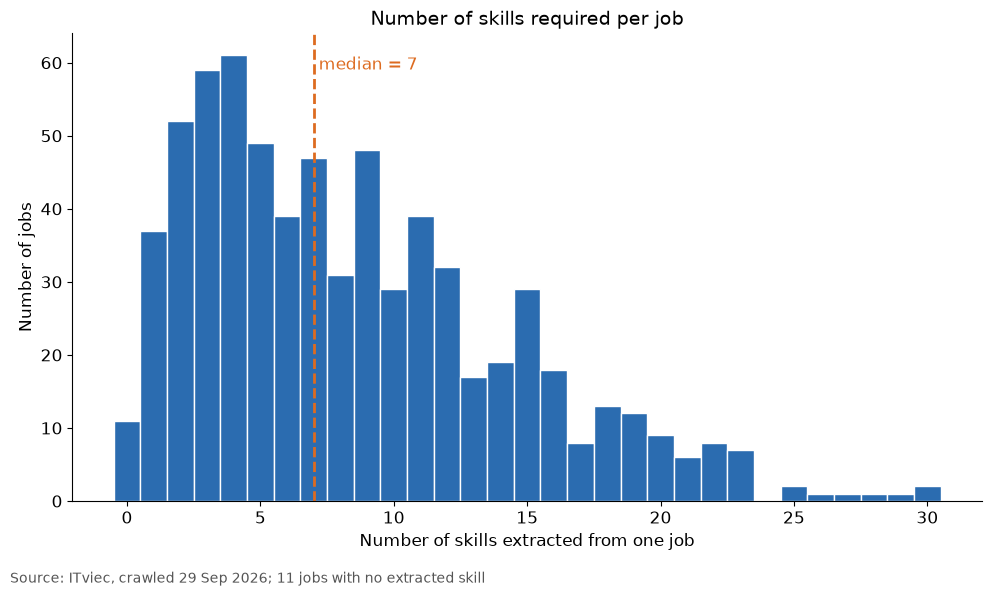

In [9]:
fig = FIGURES["skills_per_job"](jobs, skills)
save_figure(fig, "skills_per_job")  # → reports/figures/eda_skills_per_job.png

The lift matrix shows which skill pairs appear together more often than chance (lift > 1) — a preview of the association rules (Apriori) in `final_notebook.ipynb`.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_cooccurrence.png')

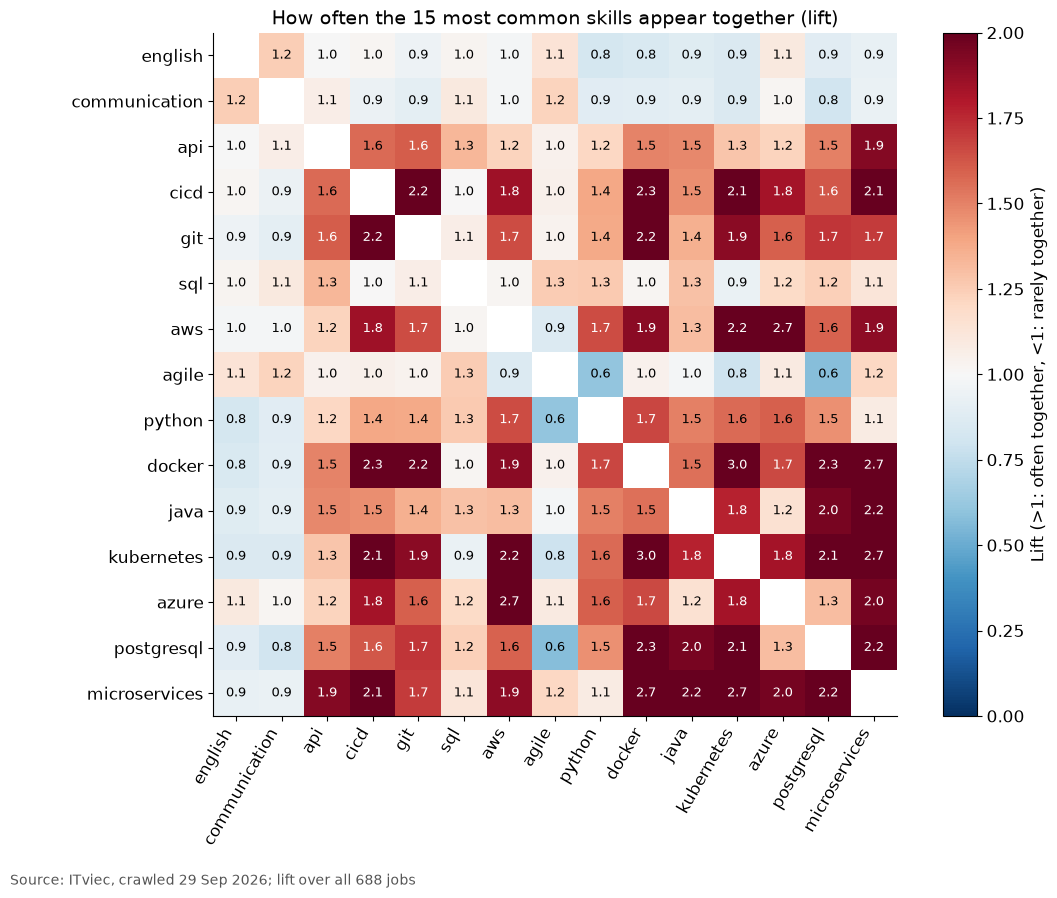

In [10]:
fig = FIGURES["cooccurrence"](jobs, skills)
save_figure(fig, "cooccurrence")  # → reports/figures/eda_cooccurrence.png

## 4. Location and seniority

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_locations.png')

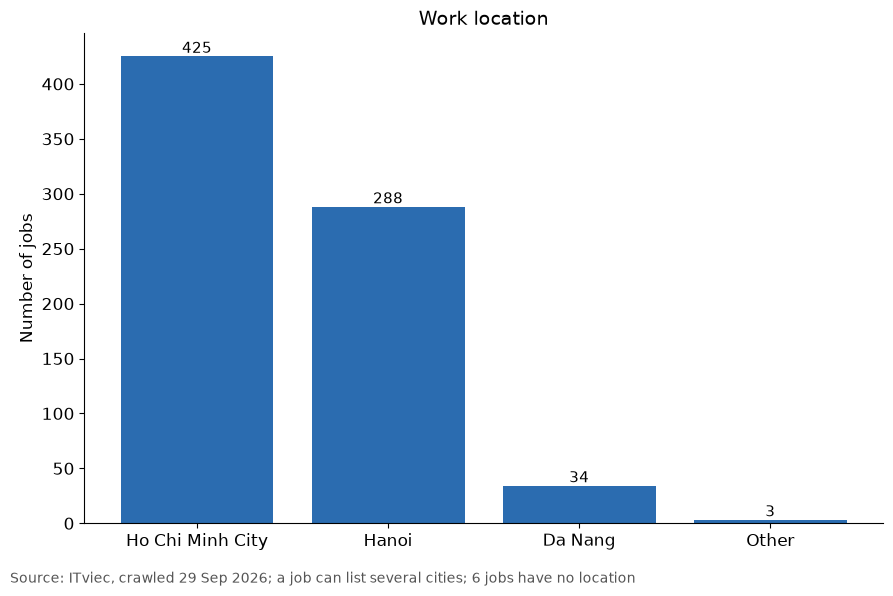

In [11]:
fig = FIGURES["locations"](jobs, skills)
save_figure(fig, "locations")  # → reports/figures/eda_locations.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_levels.png')

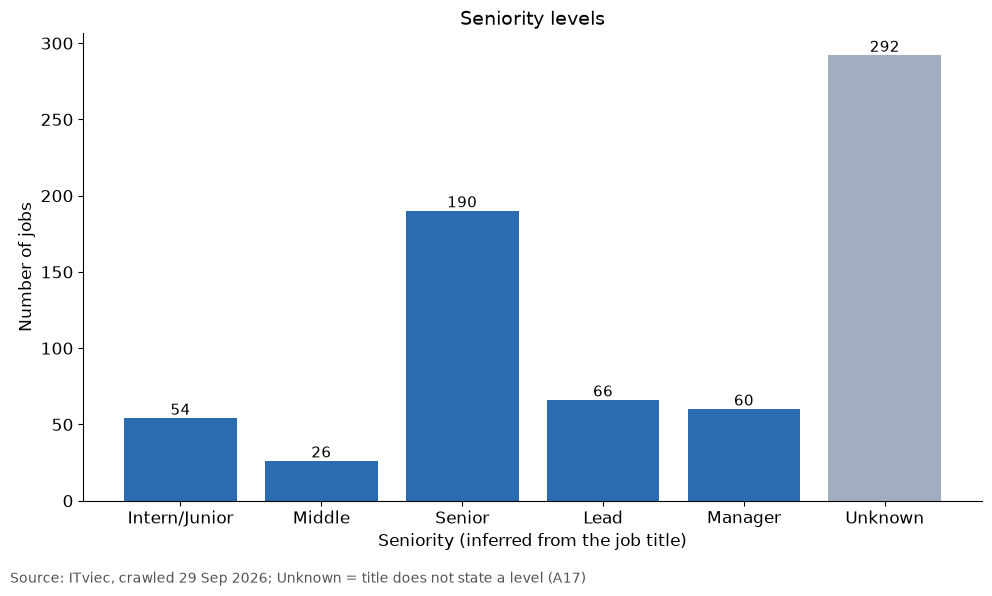

In [12]:
fig = FIGURES["levels"](jobs, skills)
save_figure(fig, "levels")  # → reports/figures/eda_levels.png

In [13]:
print(jobs["level_group"].value_counts().to_string())
print(f"\nSeniority not inferable from the title: {(jobs['level_group'] == 'Unknown').mean():.1%}")

level_group
Unknown          292
Senior           190
Lead              66
Manager           60
Intern/Junior     54
Middle            26

Seniority not inferable from the title: 42.4%


## 5. Salary by seniority and location

⚠️ Salaried jobs in the `Intern/Junior` group are mostly internships (allowance, not salary) — see `reports/classification_report.md`.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_by_level.png')

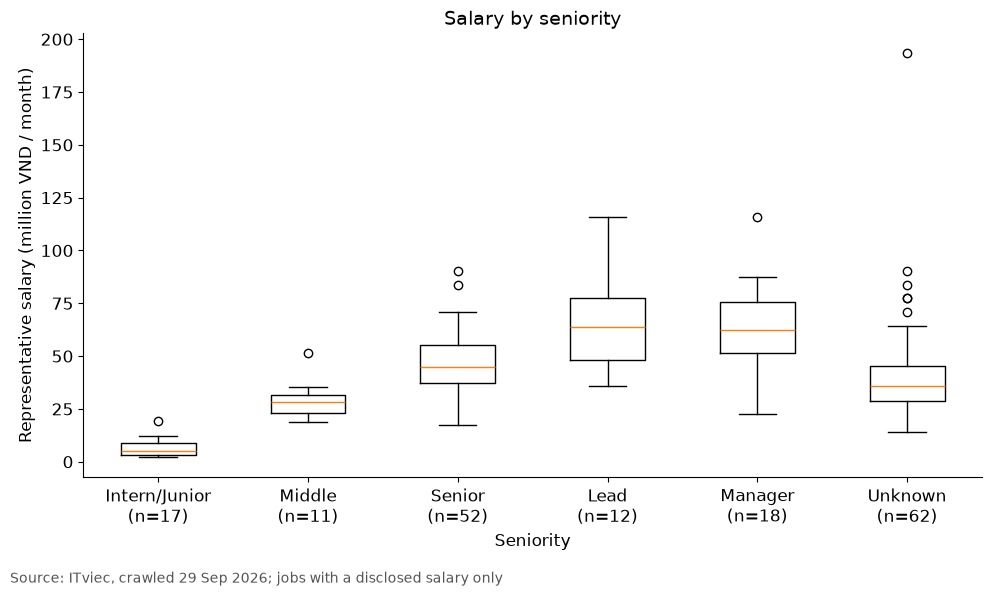

In [14]:
fig = FIGURES["salary_by_level"](jobs, skills)
save_figure(fig, "salary_by_level")  # → reports/figures/eda_salary_by_level.png

In [15]:
print(jobs[jobs["has_salary"]].groupby("level_group")["salary_mid"].agg(["count", "median"]).round(1).to_string())

               count  median
level_group                 
Intern/Junior     17     5.2
Lead              12    63.8
Manager           18    62.2
Middle            11    28.4
Senior            52    45.1
Unknown           62    36.1


PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_salary_by_location.png')

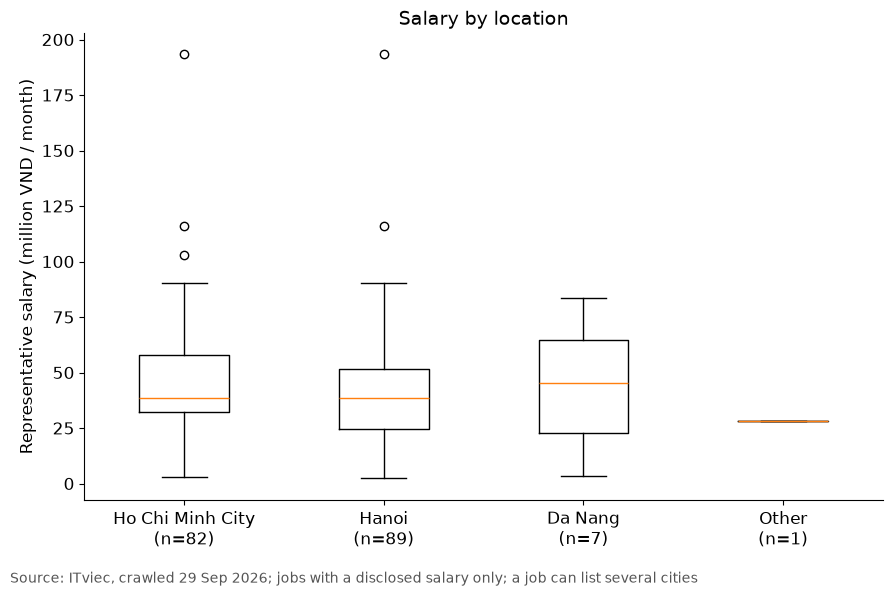

In [16]:
fig = FIGURES["salary_by_location"](jobs, skills)
save_figure(fig, "salary_by_location")  # → reports/figures/eda_salary_by_location.png

## 6. Job families

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_expertise_groups.png')

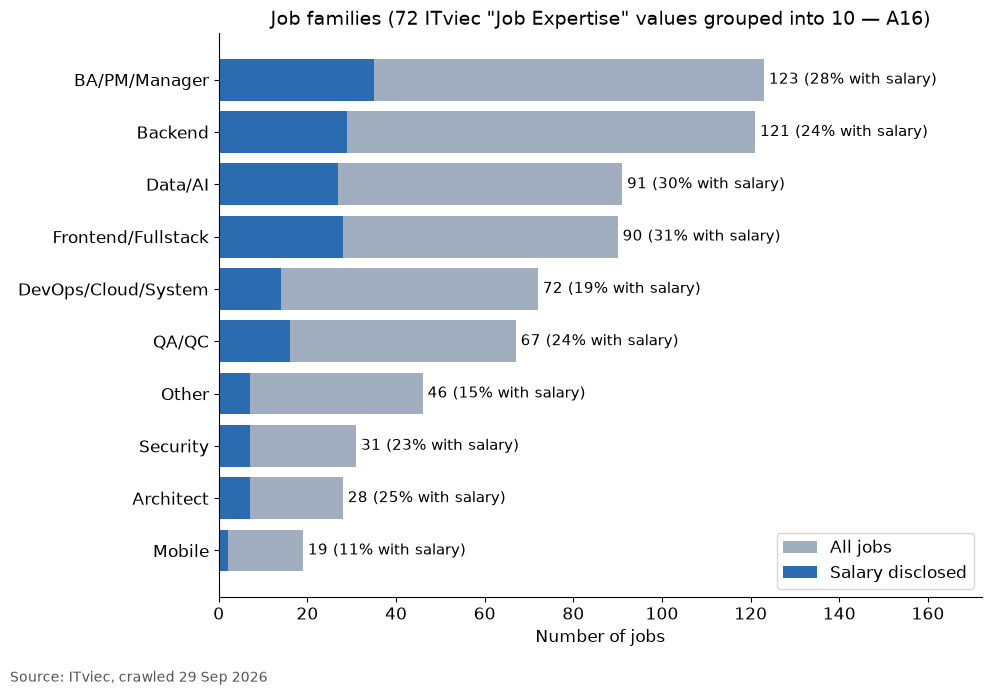

In [17]:
fig = FIGURES["expertise_groups"](jobs, skills)
save_figure(fig, "expertise_groups")  # → reports/figures/eda_expertise_groups.png

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_skills_by_group.png')

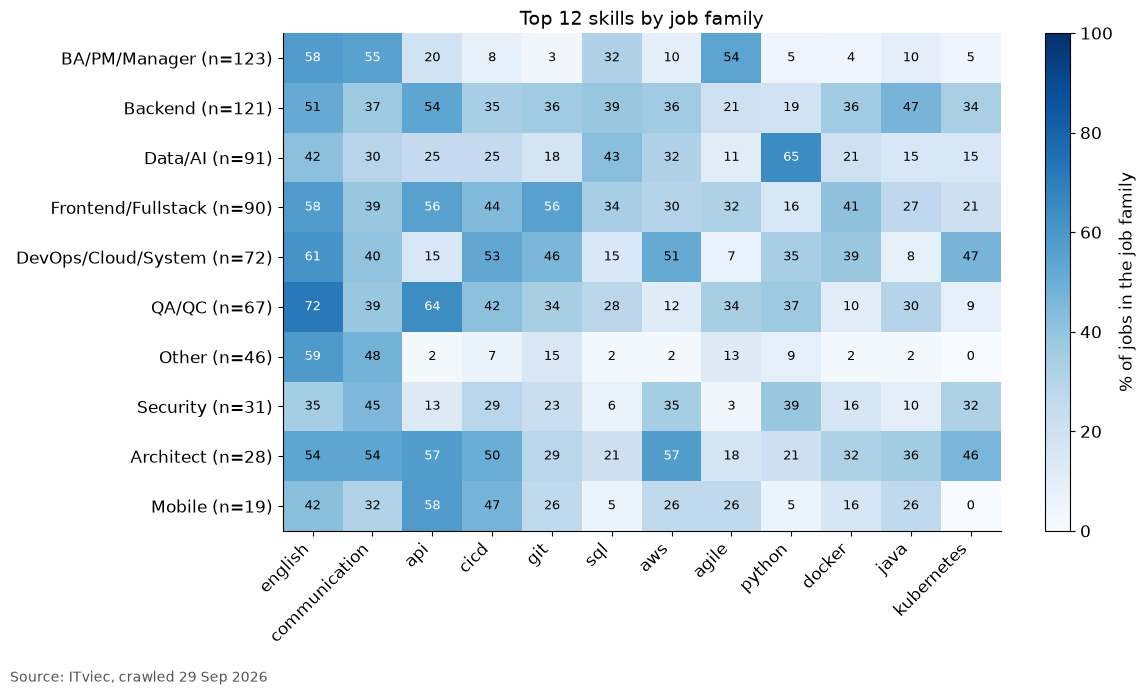

In [18]:
fig = FIGURES["skills_by_group"](jobs, skills)
save_figure(fig, "skills_by_group")  # → reports/figures/eda_skills_by_group.png

## 7. Posting dates

The data is a snapshot of jobs **still open** on 29 Sep, so older postings are rare (already expired). The 70%/30% line is the Apriori train/test split.

PosixPath('/home/ductlord/project/Labor-Market-Intelligence/reports/figures/eda_timeline.png')

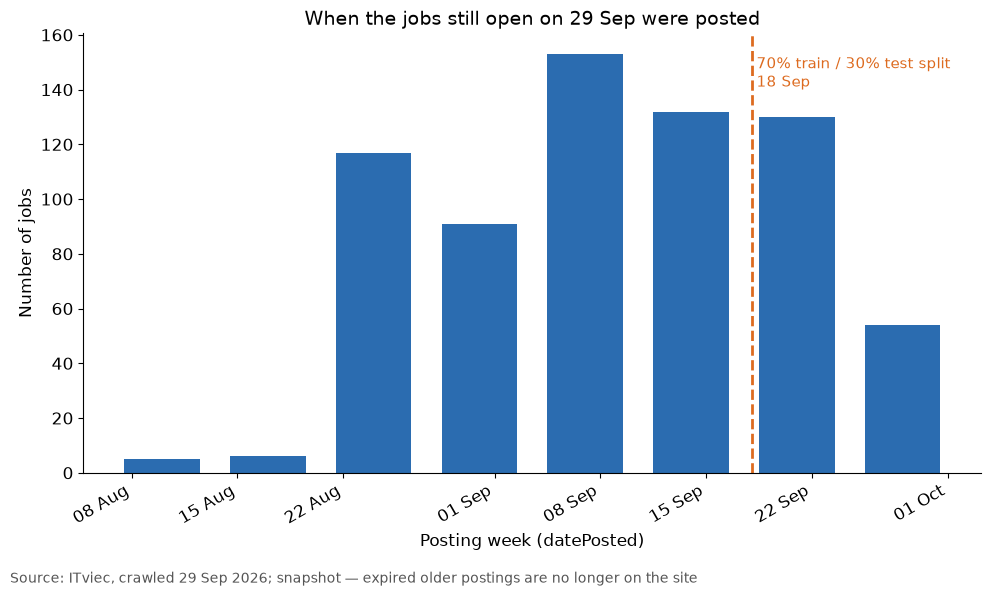

In [19]:
fig = FIGURES["timeline"](jobs, skills)
save_figure(fig, "timeline")  # → reports/figures/eda_timeline.png

In [20]:
print(f"posted_date: {jobs['posted_date'].min():%d %b %Y} → {jobs['posted_date'].max():%d %b %Y}")

posted_date: 10 Aug 2026 → 29 Sep 2026


In [21]:
saved = sorted((ROOT / "reports" / "figures").glob("eda_*.png"))
print(f"{len(saved)} EDA charts in reports/figures/:")
for p in saved: print("  ", p.name)

14 EDA charts in reports/figures/:
   eda_cooccurrence.png
   eda_currency.png
   eda_expertise_groups.png
   eda_levels.png
   eda_locations.png
   eda_pipeline_funnel.png
   eda_salary_by_level.png
   eda_salary_by_location.png
   eda_salary_disclosure.png
   eda_salary_distribution.png
   eda_skills_by_group.png
   eda_skills_per_job.png
   eda_timeline.png
   eda_top_skills.png
